# Architecture B - multi agent singel model

In [1]:
import os
import sys
import subprocess
import pathlib

REPO_URL = "https://github.com/LLM4SE-group-15/ArchitecturesForCodeDevelopmentWithLLMs.git"
REPO_DIR = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")

if not REPO_DIR.exists():
    subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)

os.chdir(REPO_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-U", "pip"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-r", "requirements.txt"], check=True)

print(f"Using repo at {REPO_DIR.resolve()}")

Cloning into '/content/ArchitecturesForCodeDevelopmentWithLLMs'...


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 48.5 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.4 requires fastcore<1.9,>=1.8.0, but you have fastcore 1.11.3 which is incompatible.


INFO: pip is looking at multiple versions of langchain-huggingface to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of langgraph-prebuilt to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 12.5 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.4/536.4 k

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
bigframes 2.26.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
google-colab 1.0.0 requires google-auth==2.38.0, but you have google-auth 2.47.0 which is incompatible.
google-colab 1.0.0 requires jupyter-server==2.14.0, but you have jupyter-server 2.12.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
cudf-cu12 25.6.0 requires pyarrow<20.0.0a0,>=14.0.0; platform_machine == "x86_64", but you have pyarrow 22.0.0 which is incompatible.
gradio 5.49.1 requires pydantic<2.12,>=2.0, but you have pydantic 2.12.5 which is incompatible.
bigframes 2.26.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
fastai

In [2]:
!pip install -r requirements.txt

In [ ]:
import os
import getpass
from huggingface_hub import login

# TOKEN PLACEHOLDER

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


ARCHITECTURE set to B


In [4]:
from huggingface_hub import HfApi

api = HfApi()
try:
    user_info = api.whoami(token=os.environ["HF_TOKEN"])
    print("Logged in to Hugging Face as:", user_info.get("name") or user_info.get("user"))
except Exception as exc:
    print("Login check failed:", exc)

Logged in to Hugging Face as: Riaburger


In [5]:
import json
import time
import logging
import pathlib
import os

from datetime import datetime

DEFAULT_ROOT = pathlib.Path("/content/ArchitecturesForCodeDevelopmentWithLLMs")
ROOT = DEFAULT_ROOT if DEFAULT_ROOT.exists() else pathlib.Path.cwd()

sys.path.insert(0, str(ROOT))

LOG_DIR = ROOT / "log"
LOG_DIR.mkdir(exist_ok=True)

logger = logging.getLogger("architecture_B")
logger.setLevel(logging.INFO)
if logger.handlers:
    logger.handlers.clear()
formatter = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
file_handler = logging.FileHandler(LOG_DIR / "architecture_B.log")
stream_handler = logging.StreamHandler()
for handler in (file_handler, stream_handler):
    handler.setFormatter(formatter)
    logger.addHandler(handler)

logger.info("Logger ready. Repo root: %s", ROOT)
logger.info("Log files: %s", LOG_DIR)
print("Logs ->", LOG_DIR)

2026-01-24 10:41:29,979 | INFO | Logger ready. Repo root: /content/ArchitecturesForCodeDevelopmentWithLLMs
2026-01-24 10:41:29,979 | INFO | Log files: /content/ArchitecturesForCodeDevelopmentWithLLMs/log


Logs -> /content/ArchitecturesForCodeDevelopmentWithLLMs/log


In [6]:
import time
import json
import random
from src.data.task_loader import HumanEvalTaskLoader
from src.graph.graph import run_graph
from src.agents.llm import Architecture

ARCH = Architecture.B
SEED_FIXED = 31

def run_humaneval_benchmark(limit: int = 15, shuffle: bool = True):
    """
    Run benchmark on HumanEval tasks.
    
    Args:
        limit: Number of tasks to run
        shuffle: If True, randomly sample tasks with fixed seed
    """
    loader = HumanEvalTaskLoader()
    all_tasks = loader.load_all()  # Carica tutti i 164 task
    
    if shuffle:
        random.seed(SEED_FIXED)
        tasks = random.sample(all_tasks, min(limit, len(all_tasks)))
    else:
        tasks = all_tasks[:limit]

    results = []
    total = len(tasks)
    logger.info("Loaded %s tasks from HumanEval (shuffle=%s, seed=%s)", total, shuffle, SEED_FIXED)
    print(f"Starting benchmark on {total} tasks...")
    
    for idx, task in enumerate(tasks, 1):
        logger.info("Running %s/%s %s", idx, total, task.task_id)
        print(f"[{idx}/{total}] Task {task.task_id} ({task.entry_point})... ", end="", flush=True)
        
        start = time.time()
        
        state = run_graph(
            task_id=task.task_id,
            task_description=task.prompt,
            test_code=task.test,
            entry_point=task.entry_point,
            architecture=ARCH,
        )

        elapsed = time.time() - start
        
        record = {
            "task_id": task.task_id,
            "entry_point": task.entry_point,
            "architecture": str(ARCH.value),
            "test_passed": state["test_passed"],
            "developer_tier": state.get("developer_tier"),
            "escalations": state["escalations"],
            "story_points_initial": state.get("story_points_initial"),
            "story_points_final": state.get("story_points_current"),
            "elapsed_seconds": elapsed,
        }
        results.append(record)
        
        logger.info(
            "Finished %s | pass=%s tier=%s escalations=%s elapsed=%.1fs",
            task.task_id,
            state["test_passed"],
            record["developer_tier"],
            record["escalations"],
            elapsed,
        )
        status_str = "PASS" if state["test_passed"] else "FAIL"
        print(f"{status_str} in {elapsed:.1f}s")

        with open(LOG_DIR / "architecture_B.jsonl", "a", encoding="utf-8") as f:
            f.write(json.dumps(record) + "\n")
            
    return results

# Esecuzione: 15 task random (seed=31 per riproducibilita)
sample_results = run_humaneval_benchmark(limit=15, shuffle=True)

# Sommario
passed_count = sum(1 for r in sample_results if r['test_passed'])
print(f"\nBenchmark Completed. Passed: {passed_count}/{len(sample_results)}")

Loading HumanEval dataset...


Generating test split:   0%|          | 0/164 [00:00<?, ? examples/s]

2026-01-24 10:41:36,426 | INFO | Loaded 15 tasks from HumanEval (shuffle=True, seed=31)
2026-01-24 10:41:36,427 | INFO | Running 1/15 HumanEval/3


Loaded 164 tasks.
Starting benchmark on 15 tasks...
[1/15] Task HumanEval/3 (below_zero)... 

2026-01-24 10:41:47,014 | INFO | Finished HumanEval/3 | pass=True tier=M escalations=1 elapsed=10.6s
2026-01-24 10:41:47,015 | INFO | Running 2/15 HumanEval/120


...

PASS in 7.6s
[14/15] Task HumanEval/114 (minSubArraySum)... 

2026-01-24 10:44:29,441 | INFO | Finished HumanEval/114 | pass=True tier=M escalations=0 elapsed=9.9s
2026-01-24 10:44:29,442 | INFO | Running 15/15 HumanEval/134


PASS in 9.9s
[15/15] Task HumanEval/134 (check_if_last_char_is_a_letter)... 

2026-01-24 10:44:58,237 | INFO | Finished HumanEval/134 | pass=False tier=L escalations=2 elapsed=28.8s


FAIL in 28.8s

Benchmark Completed. Passed: 12/15


In [7]:
!cd log && cat architecture_B.jsonl

{"task_id": "HumanEval/3", "entry_point": "below_zero", "architecture": "B", "test_passed": true, "developer_tier": "M", "escalations": 1, "story_points_initial": 2, "story_points_final": 3, "elapsed_seconds": 10.585607528686523}
{"task_id": "HumanEval/120", "entry_point": "maximum", "architecture": "B", "test_passed": true, "developer_tier": "M", "escalations": 0, "story_points_initial": 3, "story_points_final": 3, "elapsed_seconds": 12.558045387268066}
{"task_id": "HumanEval/28", "entry_point": "concatenate", "architecture": "B", "test_passed": true, "developer_tier": "M", "escalations": 1, "story_points_initial": 1, "story_points_final": 3, "elapsed_seconds": 10.887912273406982}
{"task_id": "HumanEval/100", "entry_point": "make_a_pile", "architecture": "B", "test_passed": true, "developer_tier": "S", "escalations": 0, "story_points_initial": 2, "story_points_final": 2, "elapsed_seconds": 11.5062096118927}
{"task_id": "HumanEval/36", "entry_point": "fizz_buzz", "architecture": "B", "

## Evaluation Metrics for Architecture B

This section calculates the evaluation metrics as specified in `evaluation.md`:

- **Primary Metrics**: Pass Rate, Pass@1
- **Cost Metrics**: Execution Time, API Calls
- **Pass Rate by Difficulty**: Introductory, Interview, Competition

In [8]:
import pandas as pd
import numpy as np
import json
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load results from JSONL file
log_file = LOG_DIR / "architecture_B.jsonl"
results = []
if log_file.exists():
    with open(log_file, "r", encoding="utf-8") as f:
        for line in f:
            if line.strip():
                results.append(json.loads(line))
else:
    print(f"Warning: {log_file} not found. Make sure to run the tasks first.")

df = pd.DataFrame(results)
print(f"Loaded {len(df)} task results")

# Mostra tutte le righe
pd.set_option('display.max_rows', None)
df

Loaded 15 task results


,task_id,entry_point,architecture,test_passed,developer_tier,escalations,story_points_initial,story_points_final,elapsed_seconds
0,HumanEval/3,below_zero,B,True,M,1,2,3,10.585608
1,HumanEval/120,maximum,B,True,M,0,3,3,12.558045
2,HumanEval/28,concatenate,B,True,M,1,1,3,10.887912
3,HumanEval/100,make_a_pile,B,True,S,0,2,2,11.506210
4,HumanEval/36,fizz_buzz,B,True,M,1,2,3,14.258419
5,HumanEval/11,string_xor,B,True,S,0,1,1,9.623440
6,HumanEval/35,max_element,B,True,S,0,1,1,7.186189
7,HumanEval/137,compare_one,B,False,L,1,5,8,21.723461
8,HumanEval/59,largest_prime_factor,B,True,L,1,3,8,18.701581
9,HumanEval/37,sort_even,B,True,S,0,2,2,9.670081


In [9]:
# Helper function for Wilson score confidence interval
def wilson_ci(successes, n, confidence=0.95):
    """Calculate Wilson score confidence interval for a proportion."""
    if n == 0:
        return 0, 0, 0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denominator = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * n)) / n) / denominator
    return p_hat, center - margin, center + margin

# Calculate Pass Rate (after all retries)
total_tasks = len(df)
passed_tasks = df["test_passed"].sum()
pass_rate = passed_tasks / total_tasks if total_tasks > 0 else 0

# Pass@1: tasks that passed on FIRST attempt (no escalations)
passed_first_attempt = df[(df["test_passed"] == True) & (df["escalations"] == 0)].shape[0]
pass_at_1 = passed_first_attempt / total_tasks if total_tasks > 0 else 0

# Calculate 95% Confidence Intervals
_, ci_low, ci_high = wilson_ci(passed_tasks, total_tasks)
_, ci_low_at1, ci_high_at1 = wilson_ci(passed_first_attempt, total_tasks)

print("=" * 60)
print("PRIMARY METRICS - Architecture B (Multi-Agent Single Model)")
print("=" * 60)
print(f"\nDataset: HumanEval (164 total problems)")
print(f"Tasks Evaluated: {total_tasks}")
print(f"\nPass Rate (after retries): {pass_rate:.2%} ({passed_tasks}/{total_tasks})")
print(f"  95% CI: [{ci_low:.2%}, {ci_high:.2%}]")
print(f"\nPass@1 (first attempt): {pass_at_1:.2%} ({passed_first_attempt}/{total_tasks})")
print(f"  95% CI: [{ci_low_at1:.2%}, {ci_high_at1:.2%}]")
print("=" * 60)

PRIMARY METRICS - Architecture B (Multi-Agent Single Model)

Dataset: HumanEval (164 total problems)
Tasks Evaluated: 15

Pass Rate (after retries): 80.00% (12/15)
  95% CI: [54.81%, 92.95%]

Pass@1 (first attempt): 46.67% (7/15)
  95% CI: [24.81%, 69.88%]


In [10]:
# Calculate Cost Metrics
avg_time = df["elapsed_seconds"].mean()
std_time = df["elapsed_seconds"].std()
median_time = df["elapsed_seconds"].median()
total_time = df["elapsed_seconds"].sum()
min_time = df["elapsed_seconds"].min()
max_time = df["elapsed_seconds"].max()

# For Architecture B/C: count API calls
# Base: 3 calls (Planner + Developer + Reviewer)
# + 2 additional calls per escalation (Developer + Reviewer)
df["api_calls"] = 3 + (df["escalations"] * 2)
avg_api_calls = df["api_calls"].mean()
total_api_calls = df["api_calls"].sum()

print("\n" + "=" * 60)
print("COST METRICS")
print("=" * 60)
print(f"\nExecution Time Statistics:")
print(f"  Average Time per Task: {avg_time:.2f} seconds")
print(f"  Std Dev: {std_time:.2f} seconds")
print(f"  Median Time: {median_time:.2f} seconds")
print(f"  Min Time: {min_time:.2f} seconds")
print(f"  Max Time: {max_time:.2f} seconds")
print(f"  Total Execution Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
print(f"\nAPI Calls:")
print(f"  Average API Calls per Task: {avg_api_calls:.2f}")
print(f"  Total API Calls: {total_api_calls}")
print("=" * 60)


COST METRICS

Execution Time Statistics:
  Average Time per Task: 13.45 seconds
  Std Dev: 5.82 seconds
  Median Time: 11.51 seconds
  Min Time: 7.19 seconds
  Max Time: 28.79 seconds
  Total Execution Time: 201.77 seconds (3.36 minutes)

API Calls:
  Average API Calls per Task: 4.33
  Total API Calls: 65


In [11]:
# Show per-task results
print("\n" + "=" * 60)
print("PER-TASK RESULTS")
print("=" * 60)
print("\n| Task ID           | Entry Point                  | Passed | Time (s) |")
print("|-------------------|------------------------------|--------|----------|")
for _, row in df.iterrows():
    status = "PASS" if row["test_passed"] else "FAIL"
    print(f"| {row['task_id']:<17} | {row['entry_point']:<28} | {status:<6} | {row['elapsed_seconds']:>8.2f} |")
print("=" * 60)


PER-TASK RESULTS

| Task ID           | Entry Point                  | Passed | Time (s) |
|-------------------|------------------------------|--------|----------|
| HumanEval/3       | below_zero                   | PASS   |    10.59 |
| HumanEval/120     | maximum                      | PASS   |    12.56 |
| HumanEval/28      | concatenate                  | PASS   |    10.89 |
| HumanEval/100     | make_a_pile                  | PASS   |    11.51 |
| HumanEval/36      | fizz_buzz                    | PASS   |    14.26 |
| HumanEval/11      | string_xor                   | PASS   |     9.62 |
| HumanEval/35      | max_element                  | PASS   |     7.19 |
| HumanEval/137     | compare_one                  | FAIL   |    21.72 |
| HumanEval/59      | largest_prime_factor         | PASS   |    18.70 |
| HumanEval/37      | sort_even                    | PASS   |     9.67 |
| HumanEval/8       | sum_product                  | PASS   |    12.82 |
| HumanEval/15      | string_seq

In [12]:
# Retry and Escalation Dynamics
print("\n" + "=" * 60)
print("RETRY & ESCALATION DYNAMICS")
print("=" * 60)

# Escalation distribution
escalation_counts = df["escalations"].value_counts().sort_index()
print("\n| Escalations | Count | Percentage |")
print("|-------------|-------|------------|")
for esc, count in escalation_counts.items():
    pct = 100 * count / total_tasks
    print(f"| {esc}           | {count:>5} | {pct:>10.2f}% |")

# Tier distribution (for Architecture B/C)
if "developer_tier" in df.columns and df["developer_tier"].notna().any():
    print("\n| Developer Tier | Count | Percentage |")
    print("|----------------|-------|------------|")
    tier_counts = df["developer_tier"].value_counts()
    for tier in ["S", "M", "L"]:
        if tier in tier_counts.index:
            count = tier_counts[tier]
            pct = 100 * count / total_tasks
            print(f"| {tier}              | {count:>5} | {pct:>10.2f}% |")

# Pass rate by escalation count
print("\n| Escalations | Total | Passed | Pass Rate |")
print("|-------------|-------|--------|-----------|")
for esc in sorted(df["escalations"].unique()):
    subset = df[df["escalations"] == esc]
    total = len(subset)
    passed = subset["test_passed"].sum()
    rate = passed / total if total > 0 else 0
    print(f"| {esc}           | {total:>5} | {passed:>6} | {rate:>8.2%} |")

print("=" * 60)


RETRY & ESCALATION DYNAMICS

| Escalations | Count | Percentage |
|-------------|-------|------------|
| 0           |     7 |      46.67% |
| 1           |     6 |      40.00% |
| 2           |     2 |      13.33% |

| Developer Tier | Count | Percentage |
|----------------|-------|------------|
| S              |     5 |      33.33% |
| M              |     6 |      40.00% |
| L              |     4 |      26.67% |

| Escalations | Total | Passed | Pass Rate |
|-------------|-------|--------|-----------|
| 0           |     7 |      7 |  100.00% |
| 1           |     6 |      5 |   83.33% |
| 2           |     2 |      0 |    0.00% |


In [13]:
# Story Points Analysis (B/C only)
if "story_points_initial" in df.columns and df["story_points_initial"].notna().any():
    print("\n" + "=" * 60)
    print("STORY POINTS ANALYSIS")
    print("=" * 60)
    
    sp_counts = df["story_points_initial"].value_counts().sort_index()
    print("\n| Story Points | Count | Percentage | Pass Rate |")
    print("|--------------|-------|------------|-----------|")
    for sp in [1, 2, 3, 5, 8]:
        if sp in sp_counts.index:
            count = sp_counts[sp]
            pct = 100 * count / total_tasks
            subset = df[df["story_points_initial"] == sp]
            pass_rate = subset["test_passed"].mean() * 100
            print(f"| {sp:>12} | {count:>5} | {pct:>10.1f}% | {pass_rate:>8.1f}% |")
    
    print(f"\nAvg Initial Story Points: {df['story_points_initial'].mean():.2f}")
    print(f"Avg Final Story Points: {df['story_points_final'].mean():.2f}")
    print("=" * 60)


STORY POINTS ANALYSIS

| Story Points | Count | Percentage | Pass Rate |
|--------------|-------|------------|-----------|
|            1 |     4 |       26.7% |     75.0% |
|            2 |     7 |       46.7% |     85.7% |
|            3 |     3 |       20.0% |    100.0% |
|            5 |     1 |        6.7% |      0.0% |

Avg Initial Story Points: 2.13
Avg Final Story Points: 3.87


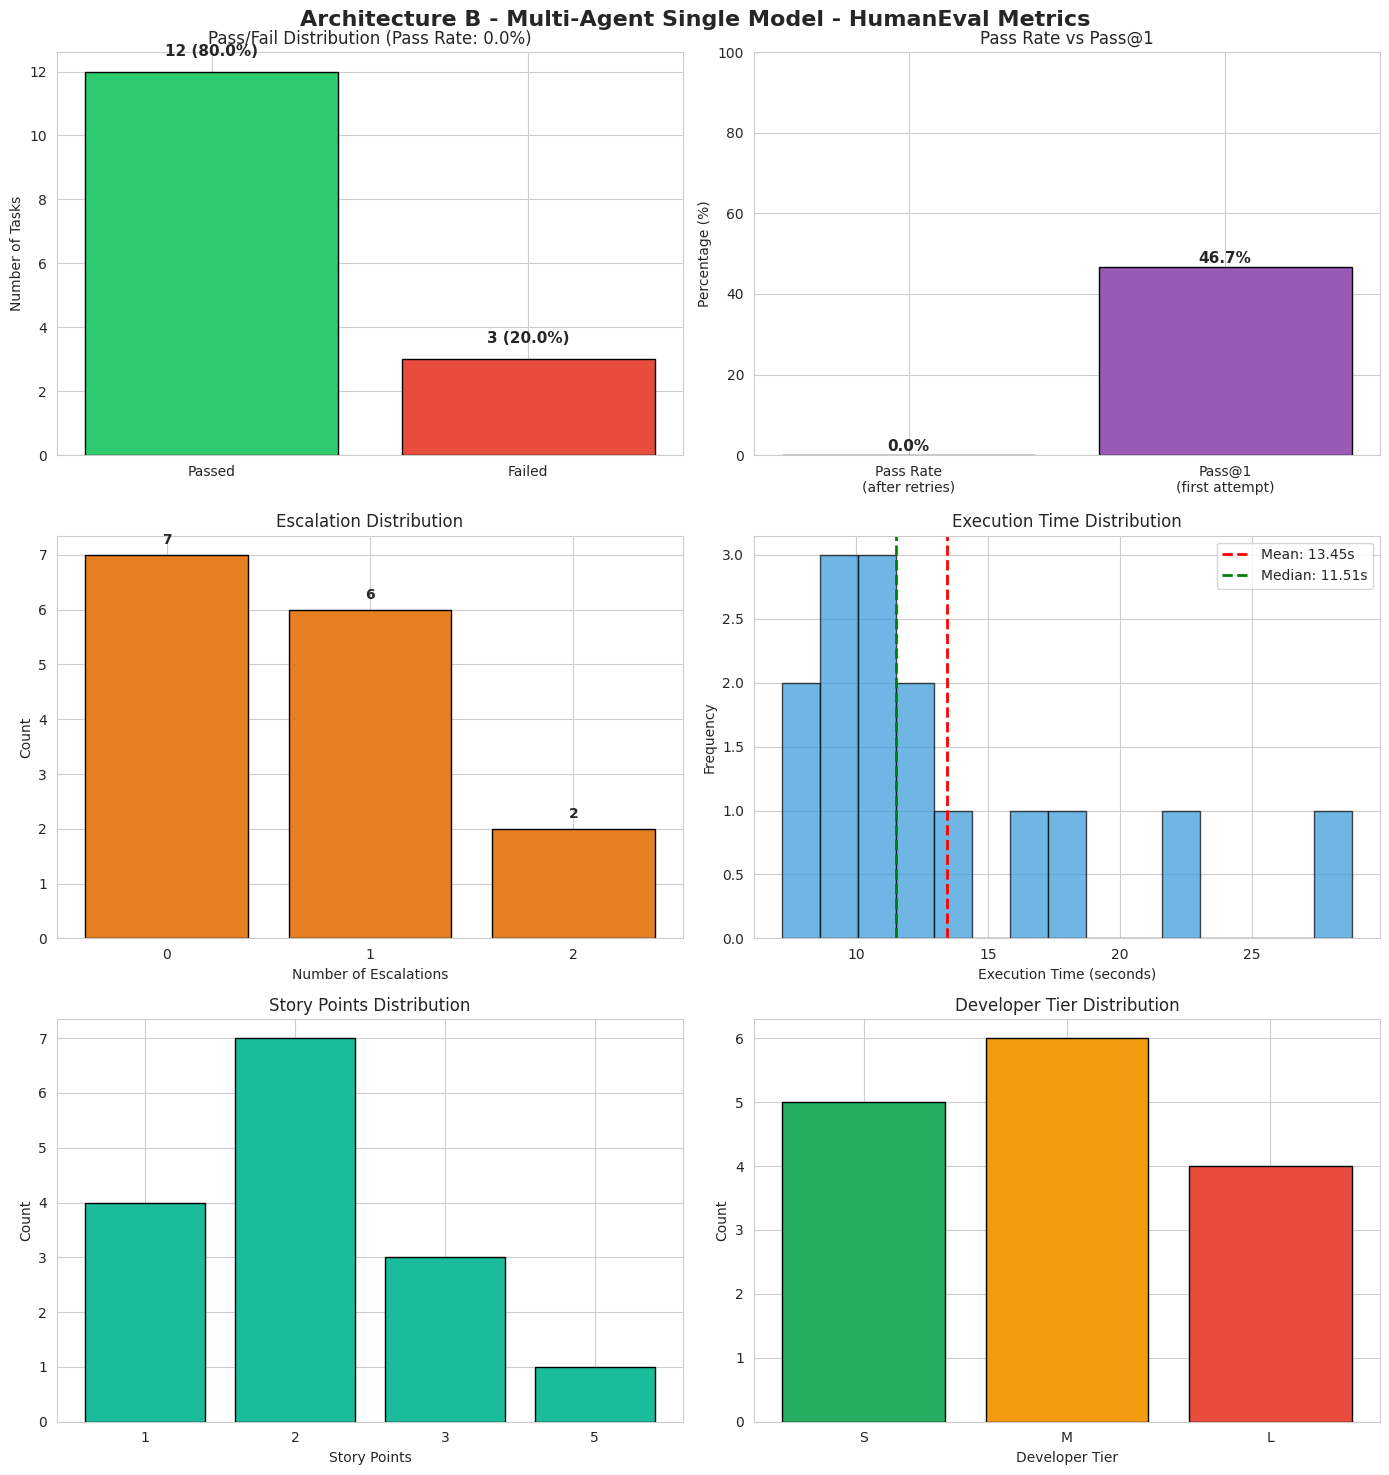


Visualization saved to: /content/ArchitecturesForCodeDevelopmentWithLLMs/log/architecture_B_metrics.png


In [14]:
# Visualizations for Architecture B/C (Extended)
sns.set_style("whitegrid")

# Determine number of rows based on available data
has_story_points = "story_points_initial" in df.columns and df["story_points_initial"].notna().any()
has_tiers = "developer_tier" in df.columns and df["developer_tier"].notna().any()
n_rows = 3 if (has_story_points or has_tiers) else 2

fig, axes = plt.subplots(n_rows, 2, figsize=(14, 5 * n_rows))
fig.suptitle("Architecture B - Multi-Agent Single Model - HumanEval Metrics", fontsize=16, fontweight="bold")

# 1. Pass/Fail Bar Chart
ax1 = axes[0, 0]
categories = ["Passed", "Failed"]
counts = [passed_tasks, total_tasks - passed_tasks]
colors = ["#2ecc71", "#e74c3c"]
bars = ax1.bar(categories, counts, color=colors, edgecolor="black")
ax1.set_ylabel("Number of Tasks")
ax1.set_title(f"Pass/Fail Distribution (Pass Rate: {pass_rate:.1%})")
for bar, count in zip(bars, counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f"{count} ({count/total_tasks:.1%})", ha="center", fontsize=11, fontweight="bold")

# 2. Pass Rate vs Pass@1 comparison
ax2 = axes[0, 1]
metrics = ["Pass Rate\n(after retries)", "Pass@1\n(first attempt)"]
values = [pass_rate * 100, pass_at_1 * 100]
colors_bar = ["#3498db", "#9b59b6"]
bars = ax2.bar(metrics, values, color=colors_bar, edgecolor="black")
ax2.set_ylabel("Percentage (%)")
ax2.set_title("Pass Rate vs Pass@1")
ax2.set_ylim(0, 100)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f"{val:.1f}%", ha="center", fontsize=11, fontweight="bold")

# 3. Escalation Distribution
ax3 = axes[1, 0]
esc_counts = df["escalations"].value_counts().sort_index()
ax3.bar(esc_counts.index.astype(str), esc_counts.values, color="#e67e22", edgecolor="black")
ax3.set_xlabel("Number of Escalations")
ax3.set_ylabel("Count")
ax3.set_title("Escalation Distribution")
for i, (esc, count) in enumerate(esc_counts.items()):
    ax3.text(i, count + 0.2, str(count), ha="center", fontweight="bold")

# 4. Execution Time Histogram
ax4 = axes[1, 1]
ax4.hist(df["elapsed_seconds"], bins=15, edgecolor="black", color="#3498db", alpha=0.7)
ax4.axvline(avg_time, color="red", linestyle="--", linewidth=2, label=f"Mean: {avg_time:.2f}s")
ax4.axvline(median_time, color="green", linestyle="--", linewidth=2, label=f"Median: {median_time:.2f}s")
ax4.set_xlabel("Execution Time (seconds)")
ax4.set_ylabel("Frequency")
ax4.set_title("Execution Time Distribution")
ax4.legend()

# 5 & 6. Story Points and Tier Distribution (if available)
if n_rows == 3:
    # Story Points Distribution
    ax5 = axes[2, 0]
    if has_story_points:
        sp_counts = df["story_points_initial"].value_counts().sort_index()
        ax5.bar(sp_counts.index.astype(str), sp_counts.values, color="#1abc9c", edgecolor="black")
        ax5.set_xlabel("Story Points")
        ax5.set_ylabel("Count")
        ax5.set_title("Story Points Distribution")
    else:
        ax5.text(0.5, 0.5, "No Story Points Data", ha="center", va="center", fontsize=14)
        ax5.set_title("Story Points Distribution")
    
    # Tier Distribution
    ax6 = axes[2, 1]
    if has_tiers:
        tier_counts = df["developer_tier"].value_counts()
        tier_order = ["S", "M", "L"]
        tier_vals = [tier_counts.get(t, 0) for t in tier_order]
        tier_colors = ["#27ae60", "#f39c12", "#e74c3c"]
        ax6.bar(tier_order, tier_vals, color=tier_colors, edgecolor="black")
        ax6.set_xlabel("Developer Tier")
        ax6.set_ylabel("Count")
        ax6.set_title("Developer Tier Distribution")
    else:
        ax6.text(0.5, 0.5, "No Tier Data", ha="center", va="center", fontsize=14)
        ax6.set_title("Developer Tier Distribution")

plt.tight_layout()
plt.savefig(LOG_DIR / "architecture_B_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nVisualization saved to: {LOG_DIR / 'architecture_B_metrics.png'}")

In [ ]:
summary_data = {
    "Metric": [
        "Architecture",
        "Dataset",
        "Total Tasks",
        "Passed Tasks",
        "Pass Rate",
        "Pass@1",
        "95% CI Pass Rate",
        "95% CI Pass@1",
        "Avg Execution Time (s)",
        "Avg API Calls per Task",
        "Total API Calls",
        "Avg Escalations",
        "Tasks with 0 escalations",
        "Tasks with 1+ escalations",
    ],
    "Value": [
        "B (Multi-Agent Single-Model)",  
        "HumanEval",
        total_tasks,
        int(passed_tasks),
        f"{pass_rate:.4f}",
        f"{pass_at_1:.4f}",
        f"[{ci_low:.4f}, {ci_high:.4f}]",
        f"[{ci_low_at1:.4f}, {ci_high_at1:.4f}]",
        f"{avg_time:.2f}",
        f"{avg_api_calls:.2f}",
        int(total_api_calls),
        f"{df['escalations'].mean():.2f}",
        int((df["escalations"] == 0).sum()),
        int((df["escalations"] > 0).sum()),
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "=" * 60)
print("SUMMARY TABLE FOR ARCHITECTURE B")
print("=" * 60)
print(summary_df.to_string(index=False))
print("=" * 60)
# Save summary
summary_df.to_csv(LOG_DIR / "architecture_B_summary.csv", index=False)
# Save detailed results
df.to_csv(LOG_DIR / "architecture_B_detailed.csv", index=False)
print(f"\nSummary saved to: {LOG_DIR / 'architecture_B_summary.csv'}")
print(f"Detailed results saved to: {LOG_DIR / 'architecture_B_detailed.csv'}")